<a href="https://colab.research.google.com/github/Amr-187/AI-ML-Bootcamp/blob/main/Stress%20Level%20PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
!pip install pyswarm

  Preparing metadata (setup.py) ... done
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4464 sha256=bf00b0adbd9726fe9f7b4ca19ad5269f971af1cba800d1587e367800843cf9bd
  Stored in directory: /root/.cache/pip/wheels/71/67/40/62fa158f497f942277cbab8199b05cb61c571ab324e67ad0d6
Successfully built pyswarm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pyswarms as ps
from pyswarm import pso

# Dataset Loading


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/AI & ML Bootcamp 2024/Bootcamp Project_Stress Level Prediction/SaYoPillow.csv', header=None)
print(df)

          0       1       2       3       4       5      6      7   8
0        sr      rr       t      lm      bo     rem     sr     hr  sl
1      93.8   25.68   91.84    16.6   89.84    99.6   1.84   74.2   3
2     91.64  25.104  91.552   15.88  89.552   98.88  1.552  72.76   3
3        60      20      96      10      95      85      7     60   1
4     85.76  23.536  90.768   13.92  88.768   96.92  0.768  68.84   3
..      ...     ...     ...     ...     ...     ...    ...    ...  ..
626    69.6   20.96   92.96   10.96   90.96    89.8   3.44   62.4   2
627   48.44  17.376  98.064   6.752  96.376   73.76  8.376  53.44   0
628  97.504  27.504   86.88  17.752  84.256  101.88      0  78.76   4
629   58.64  19.728  95.728   9.728  94.592   84.32  6.728  59.32   1
630   73.92  21.392  93.392  11.392  91.392   91.96  4.088  63.48   2

[631 rows x 9 columns]


**Fixing the Column Names**

In [ ]:
if df.shape[1] == 1:
    # Split the single column into multiple columns based on ','
    df = df[0].str.split(',', expand=True)
df.columns = ['snoring_rate', 'respiration_rate', 'body_temperature',
              'limb_movement', 'blood_oxygen', 'eye_movement',
              'sleeping_hours', 'heart_rate', 'stress_level']
df.drop([0], axis=0, inplace=True)
df

,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level
1,93.8,25.68,91.84,16.6,89.84,99.6,1.84,74.2,3
2,91.64,25.104,91.552,15.88,89.552,98.88,1.552,72.76,3
3,60,20,96,10,95,85,7,60,1
4,85.76,23.536,90.768,13.92,88.768,96.92,0.768,68.84,3
5,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0
...,...,...,...,...,...,...,...,...,...
626,69.6,20.96,92.96,10.96,90.96,89.8,3.44,62.4,2
627,48.44,17.376,98.064,6.752,96.376,73.76,8.376,53.44,0
628,97.504,27.504,86.88,17.752,84.256,101.88,0,78.76,4
629,58.64,19.728,95.728,9.728,94.592,84.32,6.728,59.32,1


In [ ]:
print(df)

    snoring_rate respiration_rate body_temperature limb_movement blood_oxygen  \
1           93.8            25.68            91.84          16.6        89.84   
2          91.64           25.104           91.552         15.88       89.552   
3             60               20               96            10           95   
4          85.76           23.536           90.768         13.92       88.768   
5          48.12           17.248           97.872         6.496       96.248   
..           ...              ...              ...           ...          ...   
626         69.6            20.96            92.96         10.96        90.96   
627        48.44           17.376           98.064         6.752       96.376   
628       97.504           27.504            86.88        17.752       84.256   
629        58.64           19.728           95.728         9.728       94.592   
630        73.92           21.392           93.392        11.392       91.392   

    eye_movement sleeping_h

# EDA

In [ ]:
df.dtypes

,0
snoring_rate,object
respiration_rate,object
body_temperature,object
limb_movement,object
blood_oxygen,object
eye_movement,object
sleeping_hours,object
heart_rate,object
stress_level,object


In [ ]:
df.describe()

,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level
count,630,630,630,630,630,630,630,630,630
unique,627,626,626,626,626,626,501,626,5
top,60,22,96,12,95,95,0,65,3
freq,2,2,2,2,2,2,127,2,126


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 1 to 630
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   snoring_rate      630 non-null    object
 1   respiration_rate  630 non-null    object
 2   body_temperature  630 non-null    object
 3   limb_movement     630 non-null    object
 4   blood_oxygen      630 non-null    object
 5   eye_movement      630 non-null    object
 6   sleeping_hours    630 non-null    object
 7   heart_rate        630 non-null    object
 8   stress_level      630 non-null    object
dtypes: object(9)
memory usage: 44.4+ KB


In [ ]:
df.isnull().sum()

,0
snoring_rate,0
respiration_rate,0
body_temperature,0
limb_movement,0
blood_oxygen,0
eye_movement,0
sleeping_hours,0
heart_rate,0
stress_level,0


<Axes: >

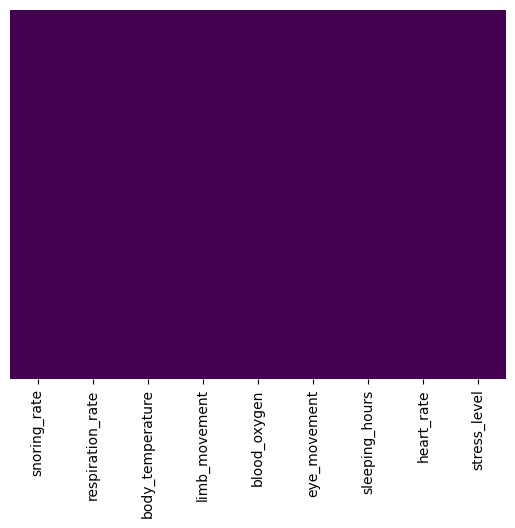

In [ ]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [ ]:
df.value_counts()

,,,,,,,,,count
snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level,
100,30,90,19,88,105,0,85,4,1
85.28,23.408,90.704,13.76,88.704,96.76,0.704,68.52,3,1
84.44,23.184,90.592,13.48,88.592,96.48,0.592,67.96,3,1
84.56,23.216,90.608,13.52,88.608,96.52,0.608,68.04,3,1
84.68,23.248,90.624,13.56,88.624,96.56,0.624,68.12,3,1
...,...,...,...,...,...,...,...,...,...
56.64,19.328,95.328,9.328,93.992,83.32,6.328,58.32,1,1
56.72,19.344,95.344,9.344,94.016,83.36,6.344,58.36,1,1
56.8,19.36,95.36,9.36,94.04,83.4,6.36,58.4,1,1


In [ ]:
df['stress_level'].value_counts()

,count
stress_level,
3,126
1,126
0,126
2,126
4,126


In [ ]:
df['sleeping_hours'].value_counts()

,count
sleeping_hours,
0,127
2,2
5,2
7,2
0.752,1
...,...
6.312,1
5.416,1
6.664,1


In [ ]:
print(df['snoring_rate'].unique())


['93.8' '91.64' '60' '85.76' '48.12' '56.88' '47' '50' '45.28' '55.52'
 '73.44' '59.28' '48.6' '96.288' '87.8' '52.32' '52.64' '86.24' '81.56'
 '63.68' '77.6' '77.28' '69.76' '88.04' '89.96' '53.68' '78.56' '50.96'
 '94.76' '62.08' '49.12' '96.256' '47.68' '99.904' '86.72' '48.48'
 '98.528' '46.12' '98.72' '60.96' '65.6' '75.36' '49.28' '73.28' '98.912'
 '62.88' '97.664' '56.72' '96.576' '49.6' '53.6' '93.2' '46.84' '56.08'
 '75.68' '97.536' '92.84' '87.56' '58.48' '98.336' '81.08' '46.6' '61.6'
 '96.448' '50.24' '49.92' '60.48' '99.136' '48.28' '50.48' '96.192'
 '57.68' '45.16' '48.68' '98.016' '96.8' '56.48' '90.08' '96' '50.64'
 '50.56' '53.92' '96.672' '68.32' '54.88' '52.4' '51.6' '92.48' '98.24'
 '65.12' '86.6' '68' '99.808' '45.2' '63.2' '98.272' '75.2' '76.96' '80'
 '99.616' '97.216' '45.04' '97.376' '53.52' '61.44' '62.24' '79.2' '96.96'
 '54.4' '68.96' '96.608' '47.44' '90.56' '66.88' '97.92' '68.64' '76'
 '49.52' '54.96' '55.28' '90.32' '97.312' '58.08' '83.6' '98.112' '98.2

In [ ]:
columns_to_convert = ['snoring_rate', 'respiration_rate', 'body_temperature','limb_movement',	'blood_oxygen',	'eye_movement',	'sleeping_hours',	'heart_rate','stress_level']
for column in columns_to_convert:
    df[column] = pd.to_numeric(df[column], errors='coerce')


In [ ]:
df.dtypes

,0
snoring_rate,float64
respiration_rate,float64
body_temperature,float64
limb_movement,float64
blood_oxygen,float64
eye_movement,float64
sleeping_hours,float64
heart_rate,float64
stress_level,int64


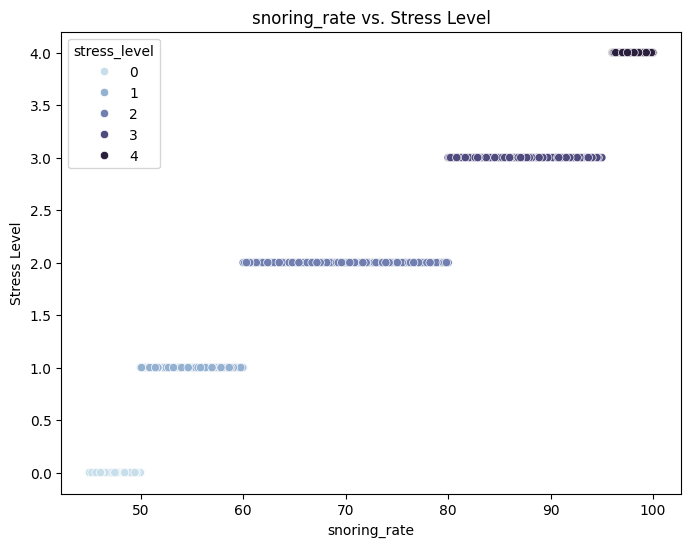

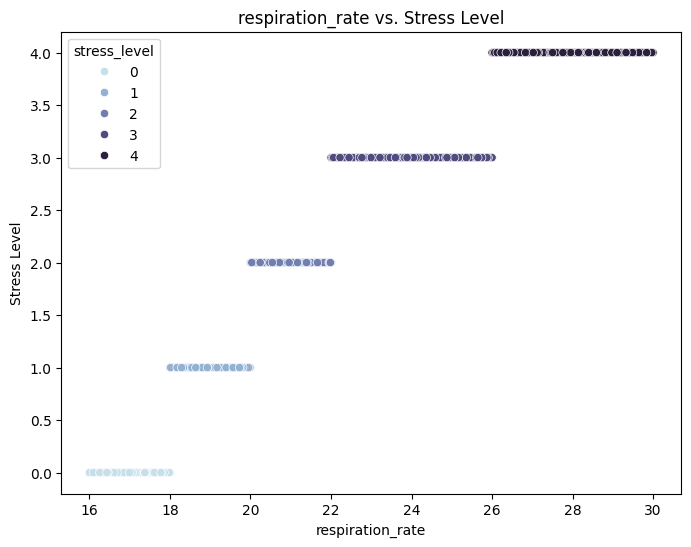

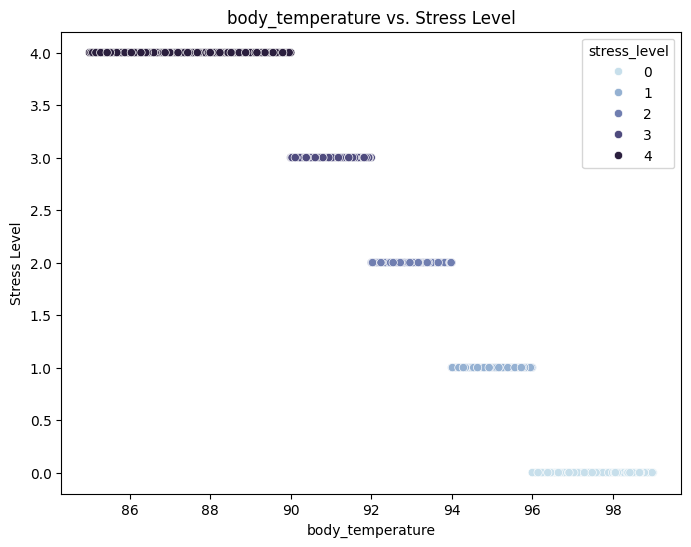

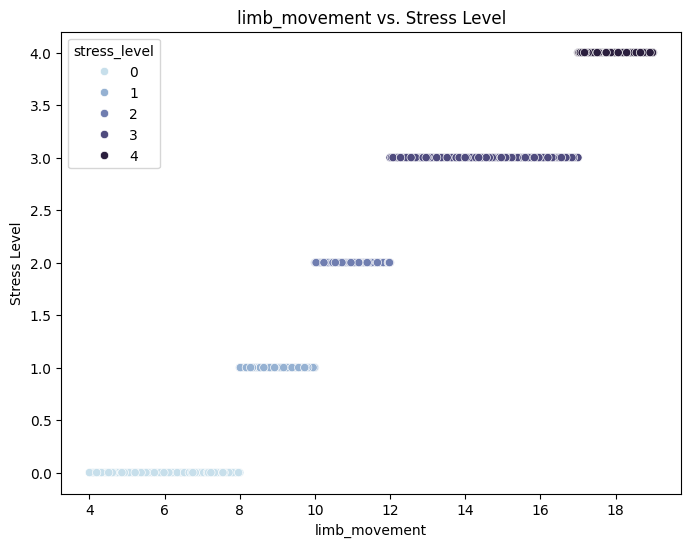

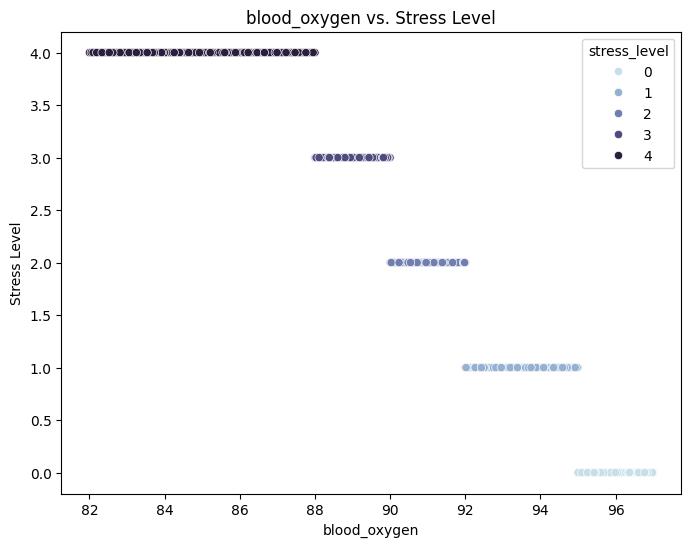

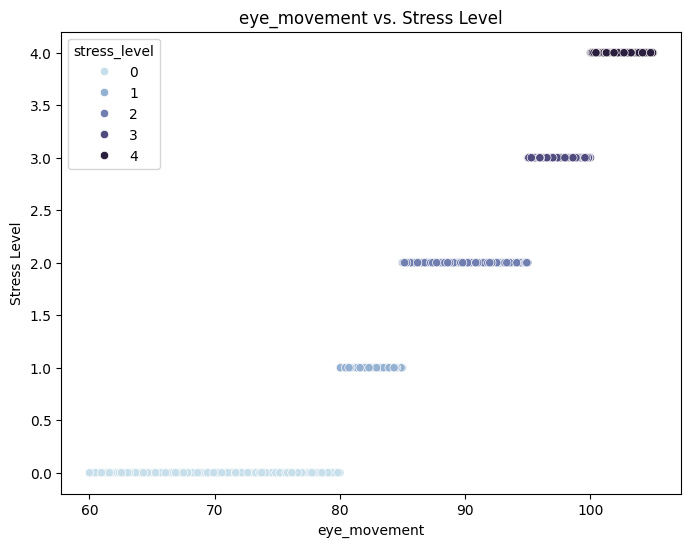

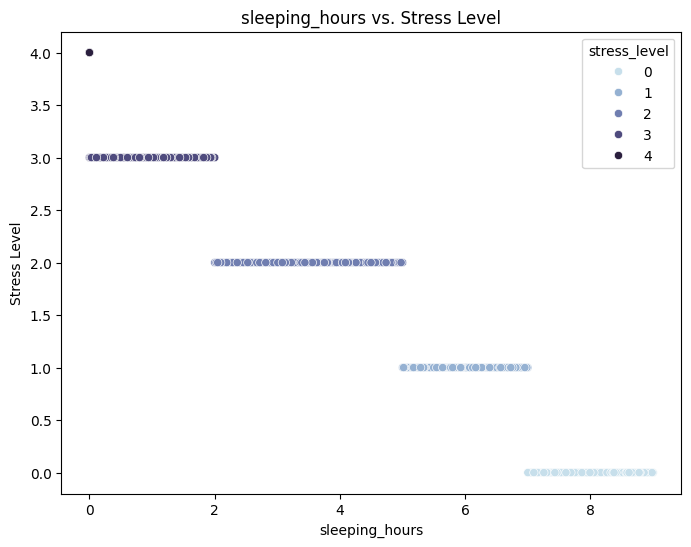

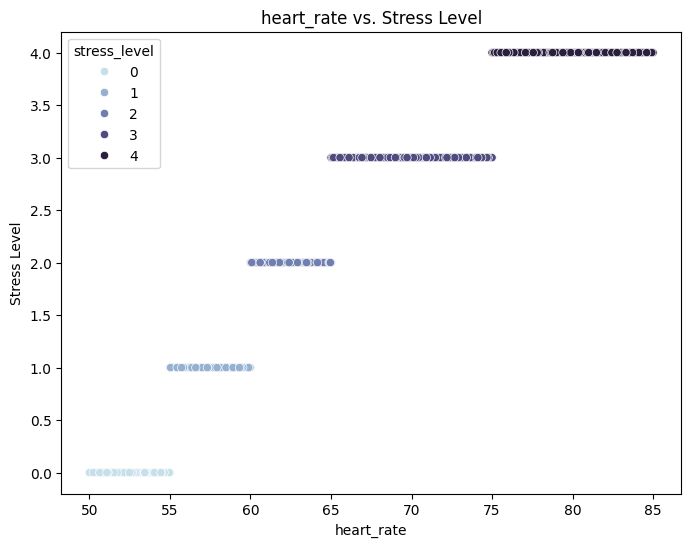

In [ ]:
for feature in df.columns[:-1]:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=feature, y='stress_level', hue='stress_level', palette="ch:s=.25,rot=-.25")
    plt.title(f"{feature} vs. Stress Level")
    plt.xlabel(feature)
    plt.ylabel("Stress Level")
    plt.show()

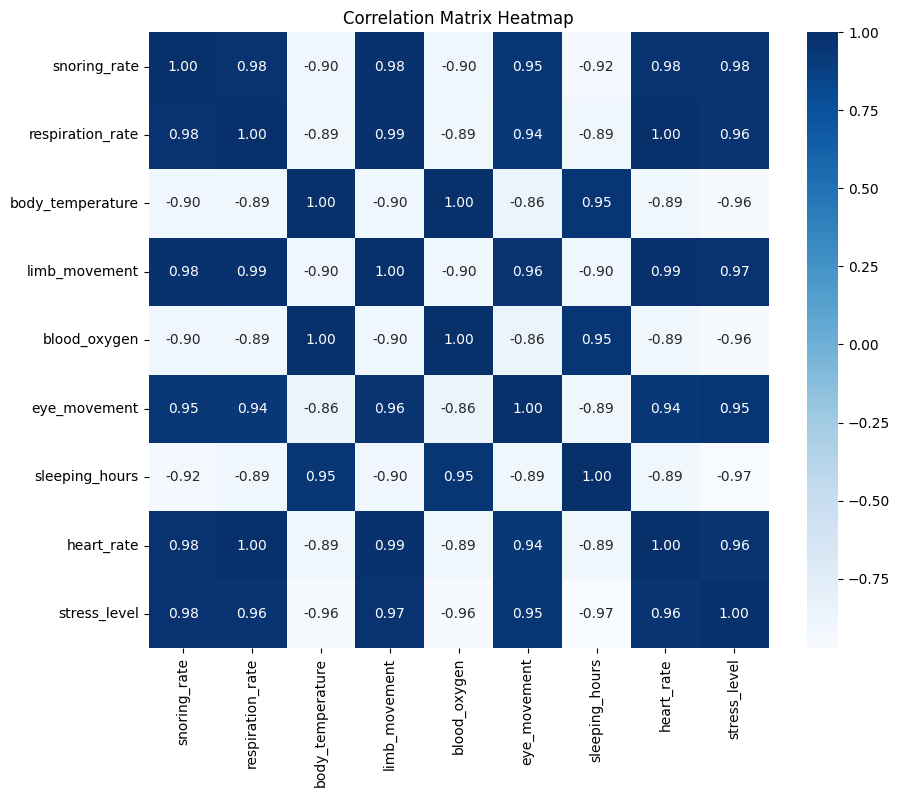

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()

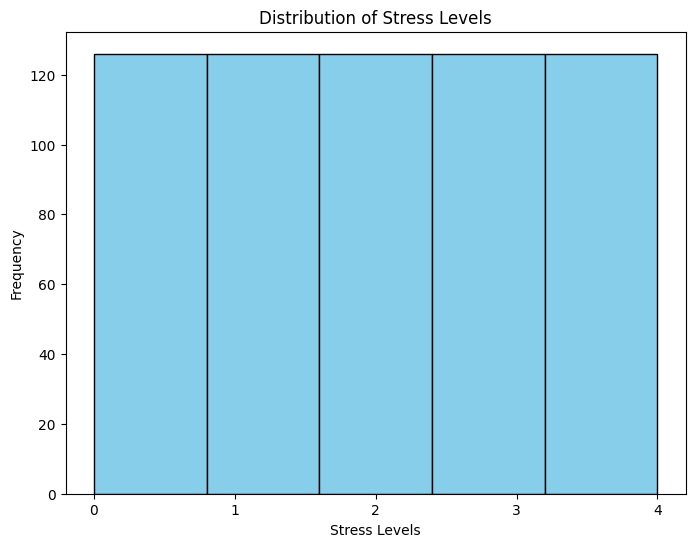

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Plot a histogram of the Stress Levels column
plt.figure(figsize=(8, 6))
plt.hist(df['stress_level'], bins=5, color='skyblue', edgecolor='black')
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Levels')
plt.ylabel('Frequency')
plt.xticks(range(5))  # Set x-axis ticks to match the Stress Levels
plt.show()

# Random Forest

In [ ]:
# Split dataset into features and target
X = df.drop(columns=['stress_level'])  # Features
y = df['stress_level']  # Target


In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
print(y_train.unique())

[0 1 2 3 4]


In [ ]:

# Initialize the Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9841269841269841
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.96      0.98        24
           2       1.00      1.00      1.00        28
           3       1.00      0.96      0.98        26
           4       0.96      1.00      0.98        25

    accuracy                           0.98       126
   macro avg       0.98      0.98      0.98       126
weighted avg       0.98      0.98      0.98       126



**Hyperparameter Tuning using Random Search**

In [ ]:
# Define the hyperparameter space to search randomly
#param_dist = {
    'n_estimators': np.arange(100, 500, 100),  # Random search over a range of number of trees
    'max_depth': [None] + list(np.arange(5, 20, 5)),  # Random search for maximum depth, including None (unlimited depth)
    'min_samples_split': np.arange(2, 10, 2),   # Random search for minimum samples required to split a node
    'min_samples_leaf': np.arange(1, 5, 1),    # Random search for minimum samples required at a leaf node
    'bootstrap': [True, False]                  # Randomly select whether to use bootstrap sampling
}

# Initialize RandomizedSearchCV with the model, parameter distribution, and number of iterations
#random_search = RandomizedSearchCV(estimator=clf, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)

#  Fit the random search model to the training data
#random_search.fit(X_train, y_train)

#  Retrieve the best hyperparameters found
#print("Best Hyperparameters:", random_search.best_params_)

# Evaluate the model on the test set using the best parameters
#best_model = random_search.best_estimator_
#y_pred = best_model.predict(X_test)

# Calculate and print the accuracy of the model
#accuracy = accuracy_score(y_test, y_pred)
#print("Test Set Accuracy:", accuracy)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}
Test Set Accuracy: 0.9841269841269841


# Random Forest with PSO

In [ ]:
# Define fitness function for PSO
def fitness_function(solution, X, y, X_test, y_test):
    selected_features_indices = np.where(solution == 1)[0]
    if len(selected_features_indices) == 0:  # If no features are selected
        return np.inf  # Return a high cost to avoid selecting no features
    if (selected_features_indices >= X.shape[1]).any():
        return np.inf  # Return a high cost if any selected feature index is out of bounds
    selected_features = X.iloc[:, selected_features_indices]
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(selected_features, y)
    y_pred = clf.predict(X_test.iloc[:, selected_features_indices])
    return -accuracy_score(y_test, y_pred)  # Negative accuracy for minimization

In [ ]:
# Define PSO optimizer
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 30, 'p': 2}
optimizer = ps.discrete.BinaryPSO(n_particles=30, dimensions=X.shape[1], options=options)

In [ ]:
# Run PSO to optimize feature selection
cost, pos = optimizer.optimize(fitness_function, iters=1000, X=X_train, y=y_train, X_test=X_test, y_test=y_test)

2024-10-24 12:25:03,295 - pyswarms.discrete.binary - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 30, 'p': 2}
pyswarms.discrete.binary:   0%|          |0/1000, best_cost=inf/usr/local/lib/python3.10/dist-packages/pyswarms/discrete/binary.py:221: RuntimeWarning: invalid value encountered in scalar subtract
  np.abs(self.swarm.best_cost - best_cost_yet_found)
pyswarms.discrete.binary: 100%|██████████|1000/1000, best_cost=inf
2024-10-24 12:25:06,730 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: inf, best pos: [1 0 1 0 0 0 1 1]


In [ ]:
# Select best features based on optimized solution
selected_features_indices = np.where(pos == 1)[0]
selected_features = X_train.iloc[:, selected_features_indices]
selected_feature_names = selected_features.columns.tolist()
print("Selected Features:", selected_feature_names)


Selected Features: ['snoring_rate', 'body_temperature', 'sleeping_hours', 'heart_rate']


In [ ]:
#valid_indices = y_train.dropna().index
#selected_features = selected_features.loc[valid_indices]
#y_train = y_train.dropna()


In [ ]:
print("Shape of selected_features:", selected_features.shape)
print("Shape of y_train:", y_train.shape)

Shape of selected_features: (504, 4)
Shape of y_train: (504,)


In [ ]:
# Train Random Forest classifier using selected features
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(selected_features, y_train)

# Evaluate Random Forest classifier
y_pred = clf.predict(X_test.iloc[:, selected_features_indices])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9920634920634921
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.96      0.98        24
           2       1.00      1.00      1.00        28
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        25

    accuracy                           0.99       126
   macro avg       0.99      0.99      0.99       126
weighted avg       0.99      0.99      0.99       126



In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['y_test'], df['y_pred'], color='blue', marker='o')
plt.plot([df['y_test'].min(), df['y_test'].max()],
         [df['y_test'].min(), df['y_test'].max()], 'r--')  # Diagonal line
plt.title('Scatter Plot of y_pred vs y_test')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.grid(True)
plt.axis('equal')  # Equal scaling
plt.show()

KeyError: 'y_test'

<Figure size 800x600 with 0 Axes>

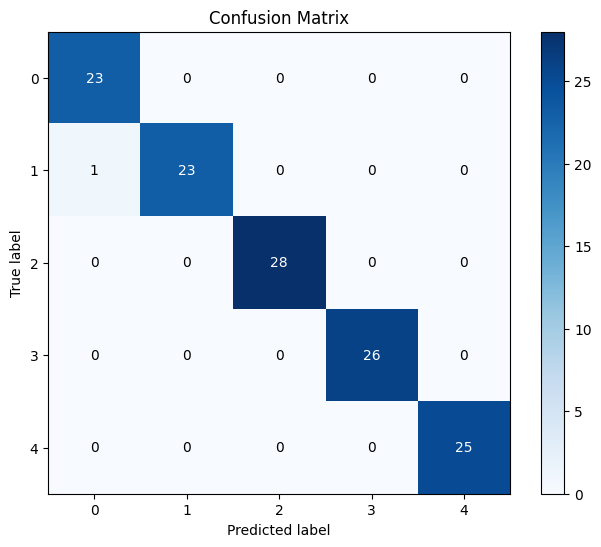

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
# Add actual values in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
        plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()



In [ ]:
!pip install shap

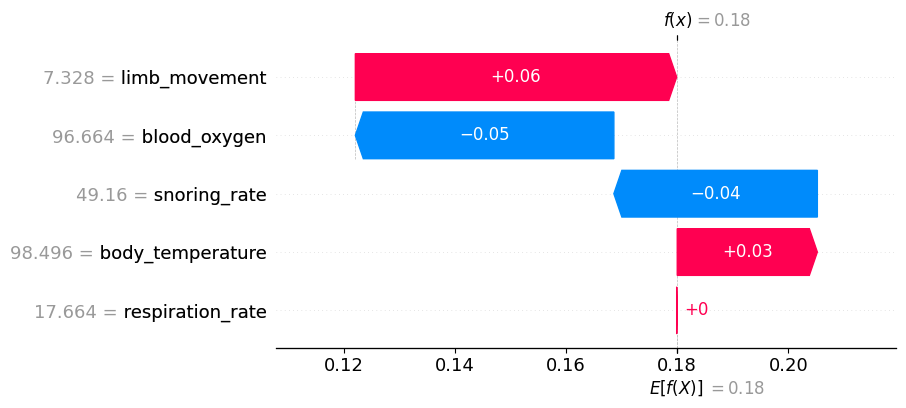

In [ ]:
import shap
explainer = shap.TreeExplainer(clf,X_train)
shap_values = explainer.shap_values(X_test)

# Create an Explanation object for the first instance
# For binary classification, use shap_values[1] for the positive class
first_instance_shap = shap.Explanation(values=shap_values[1][0],
                                        base_values=explainer.expected_value[1],
                                        data=X_test.iloc[0])

# Create a waterfall plot for the first instance
shap.waterfall_plot(first_instance_shap)

# Show the plot
plt.show()


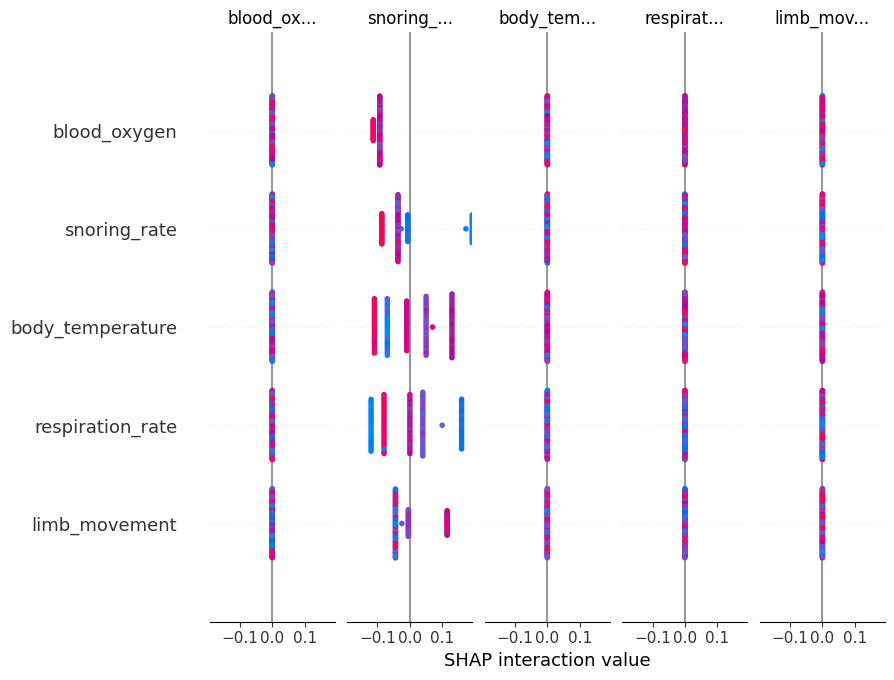

In [ ]:
explainer = shap.Explainer(clf, X_train)  # Use training data for the explainer
shap_values = explainer(X_test)  # Calculate SHAP values for test data

shap_values_np = shap_values.values
shap.summary_plot(shap_values_np, X_test,plot_type="dot")
plt.show()

In [ ]:
np.shape(shap_values)

(504, 8, 5)

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0, :, 0], X_test.iloc[0, :])  # For class 0

/usr/local/lib/python3.10/dist-packages/shap/plots/_force_matplotlib.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


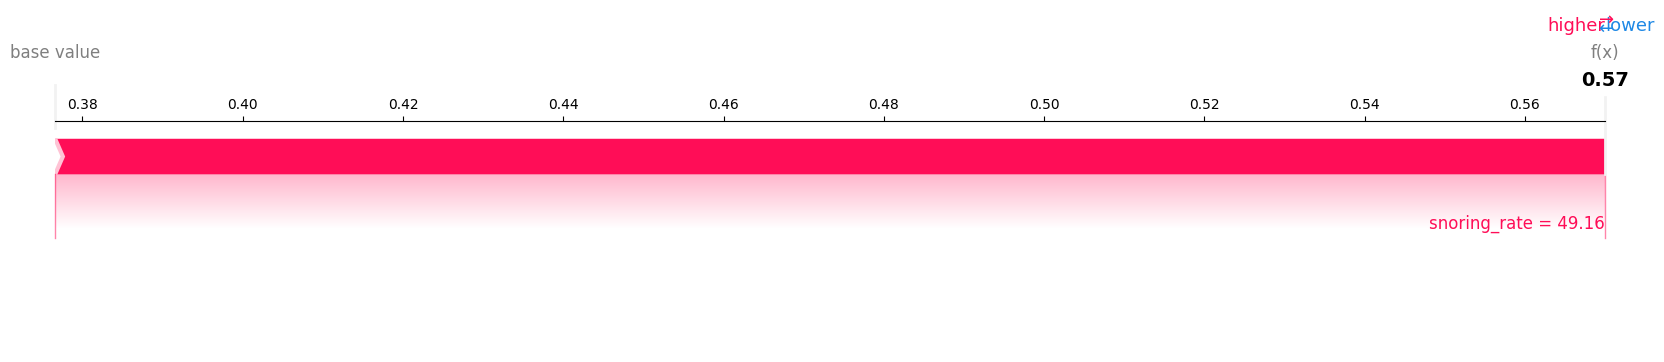

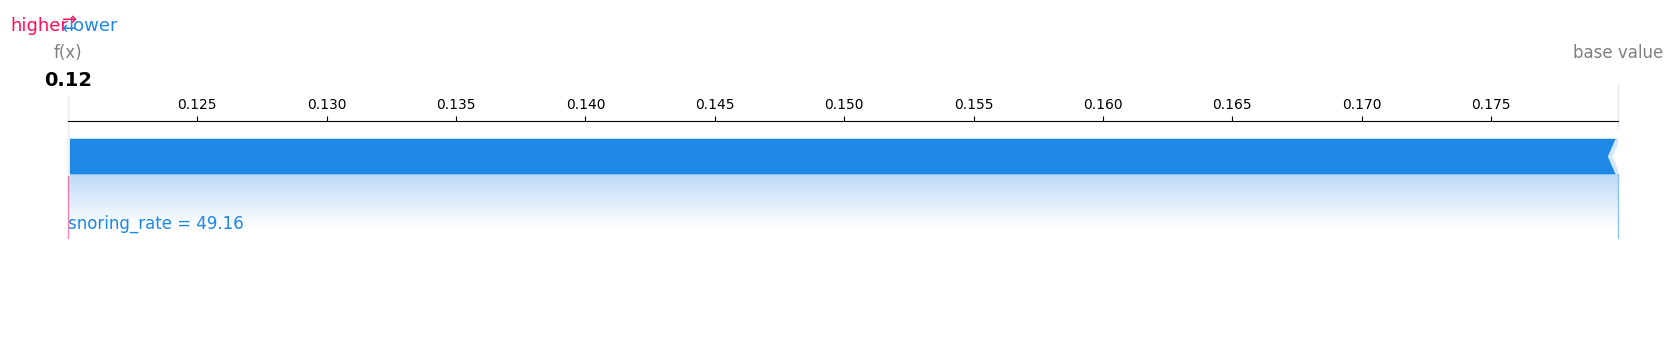

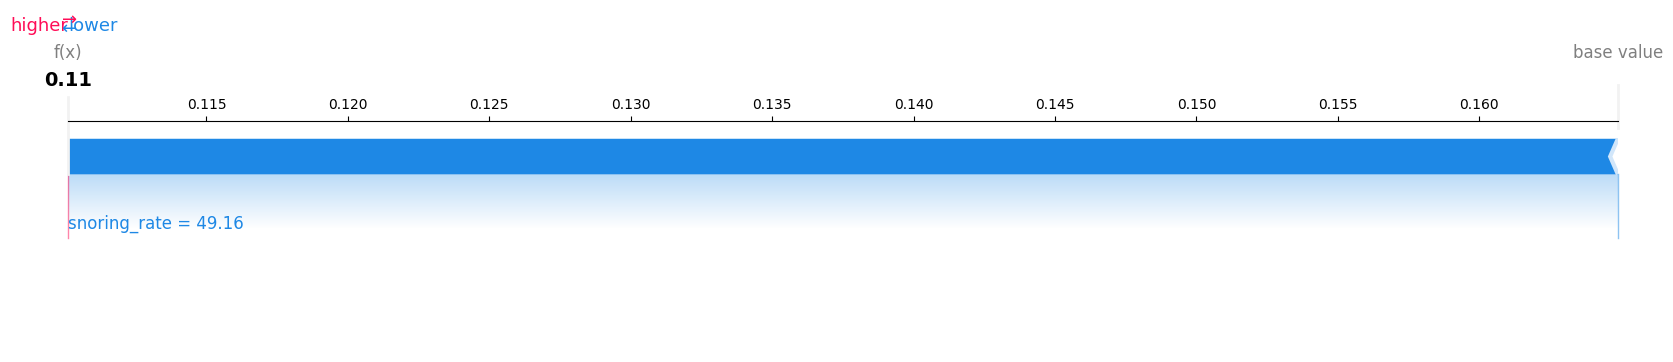

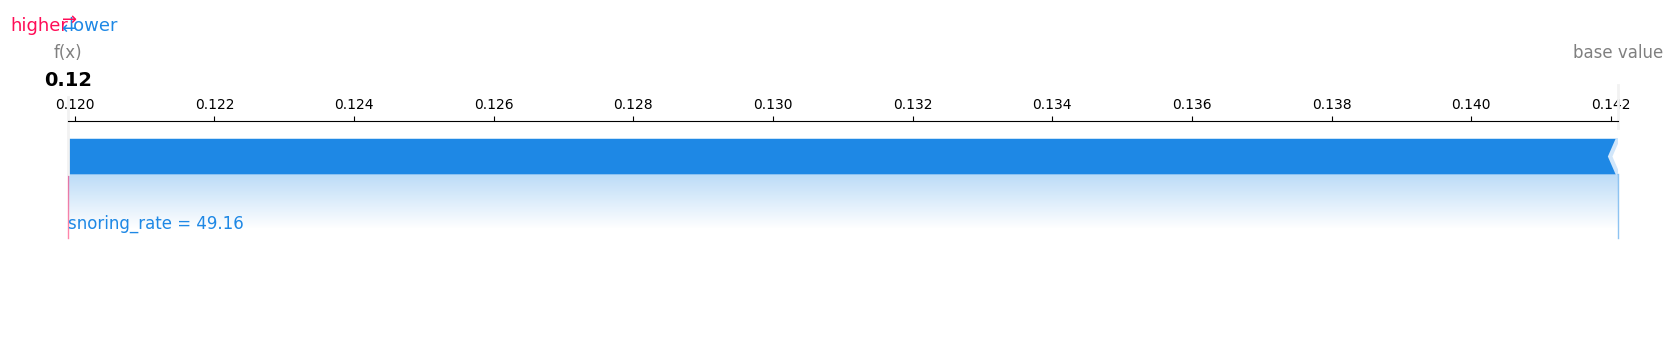

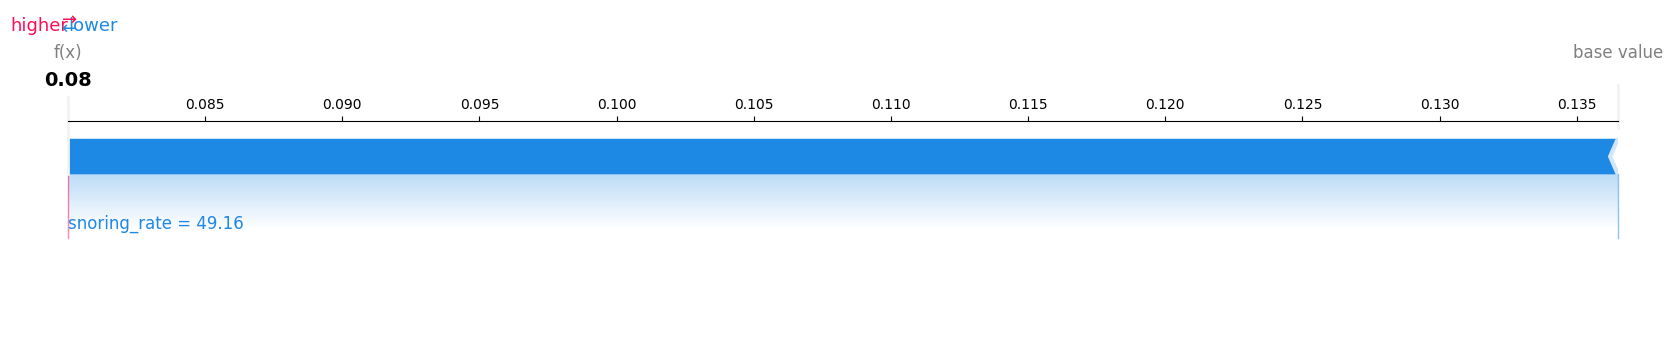

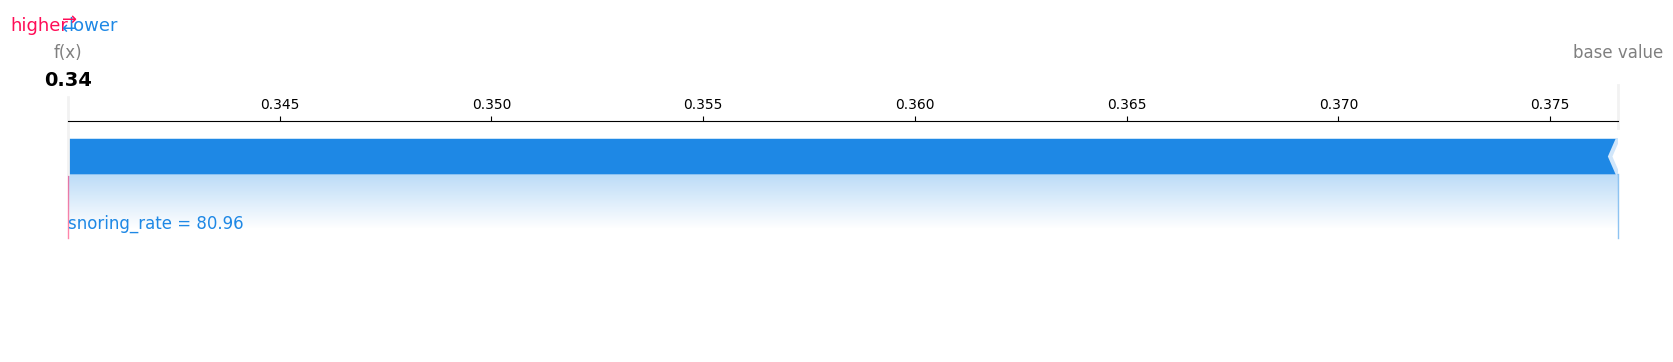

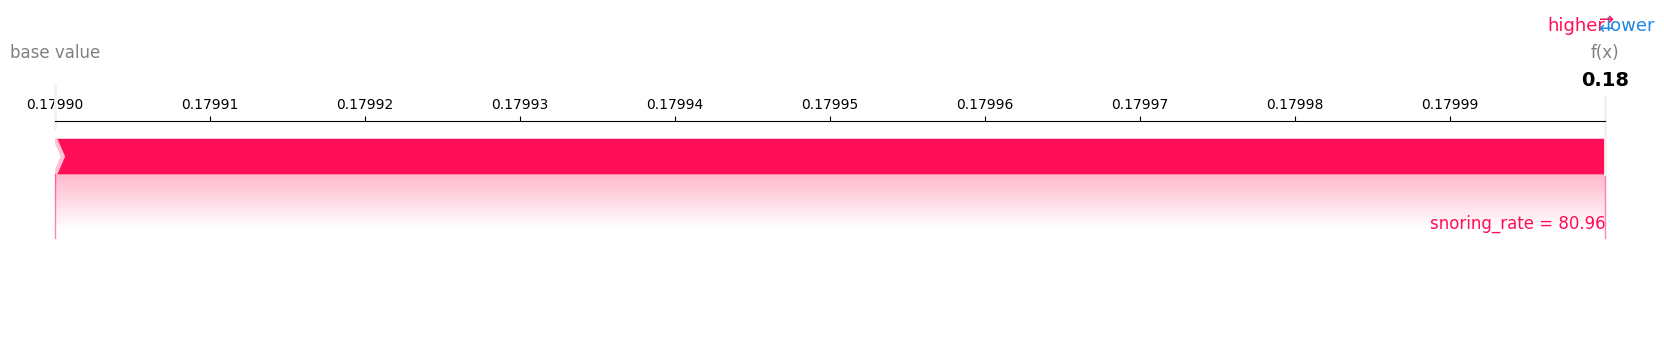

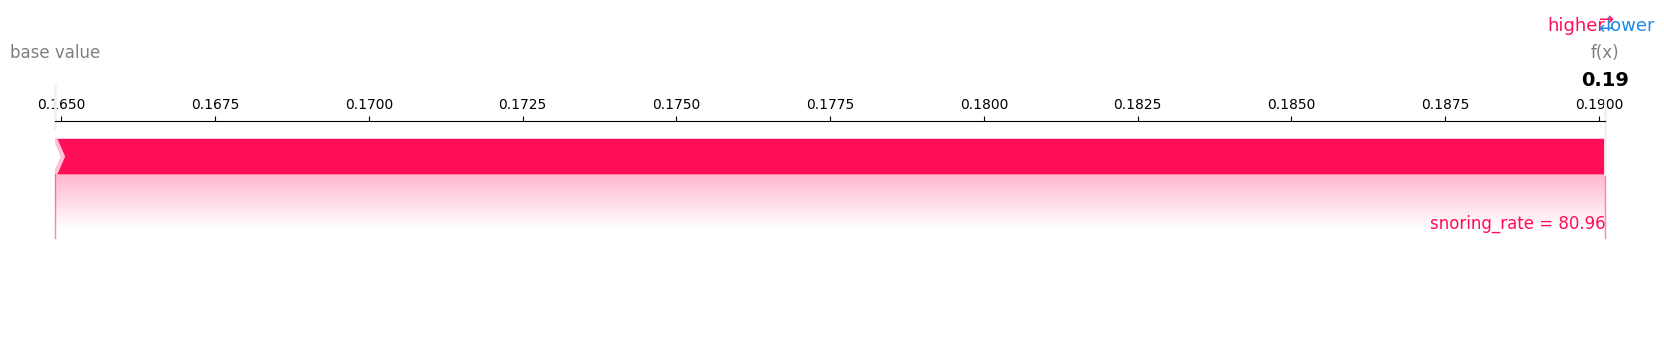

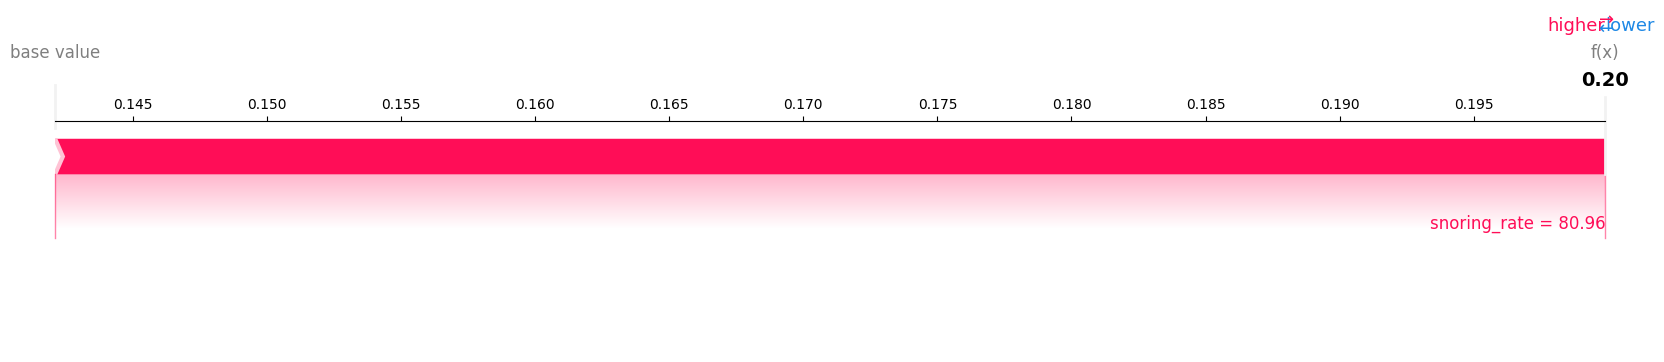

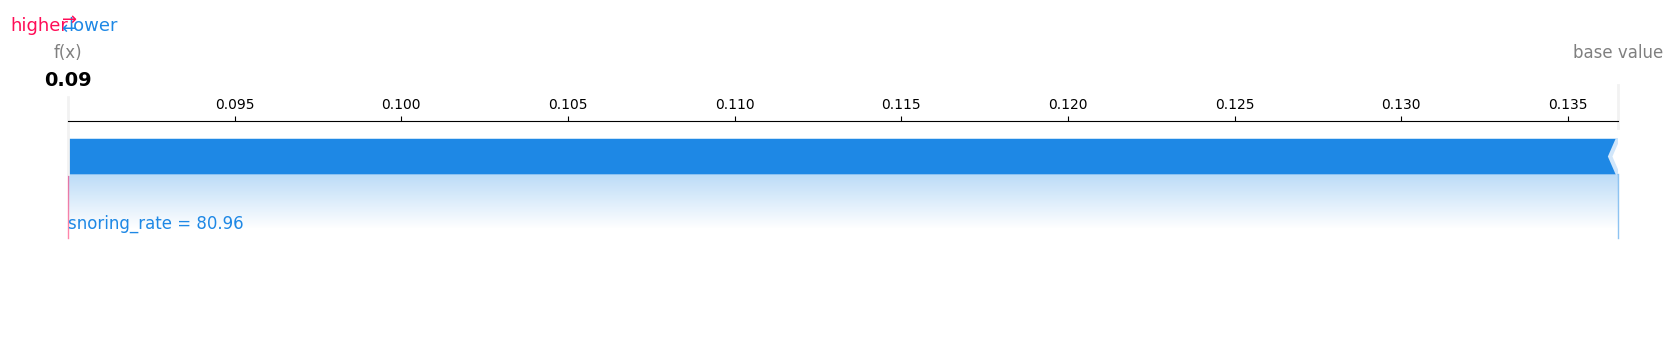

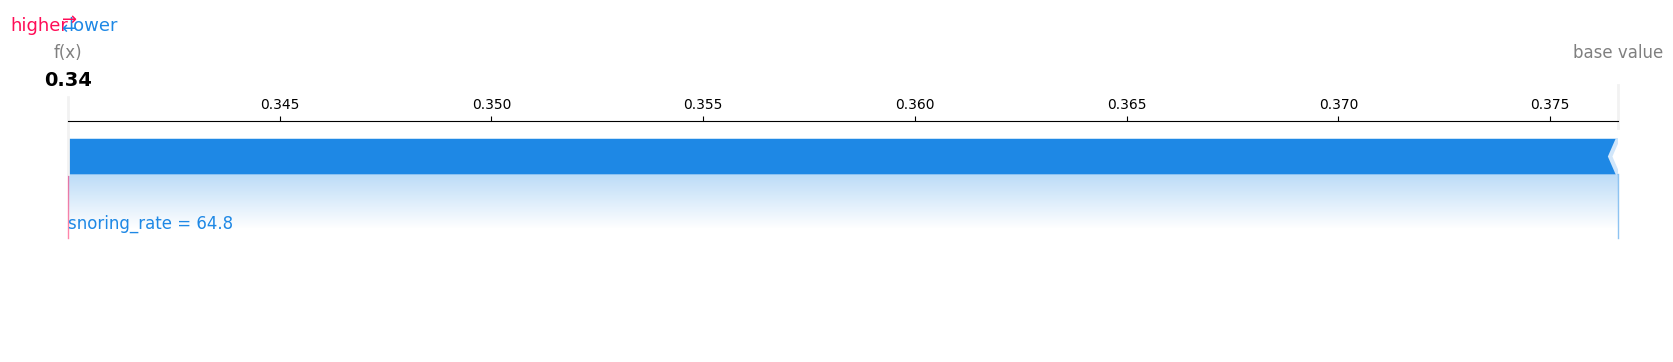

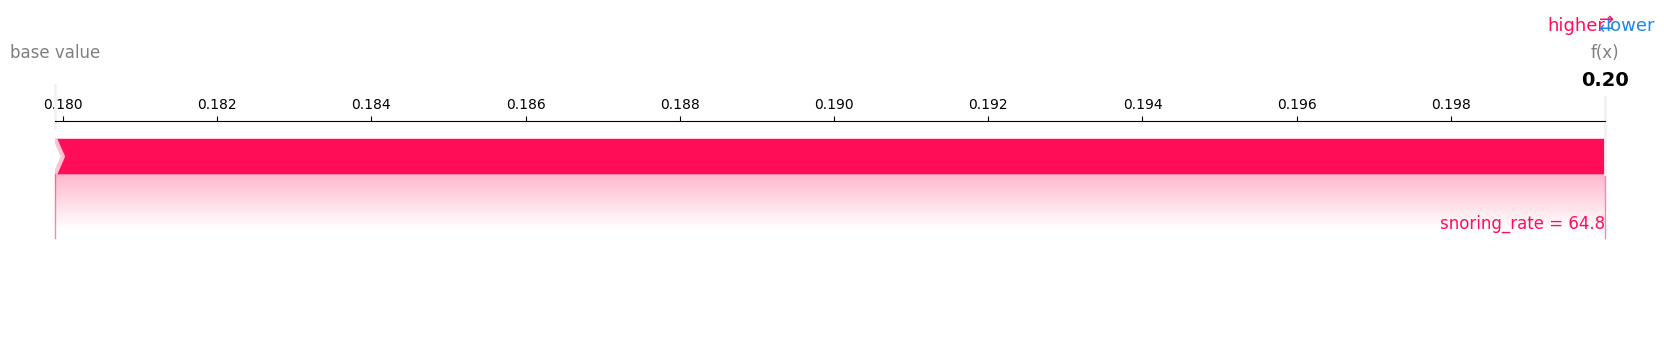

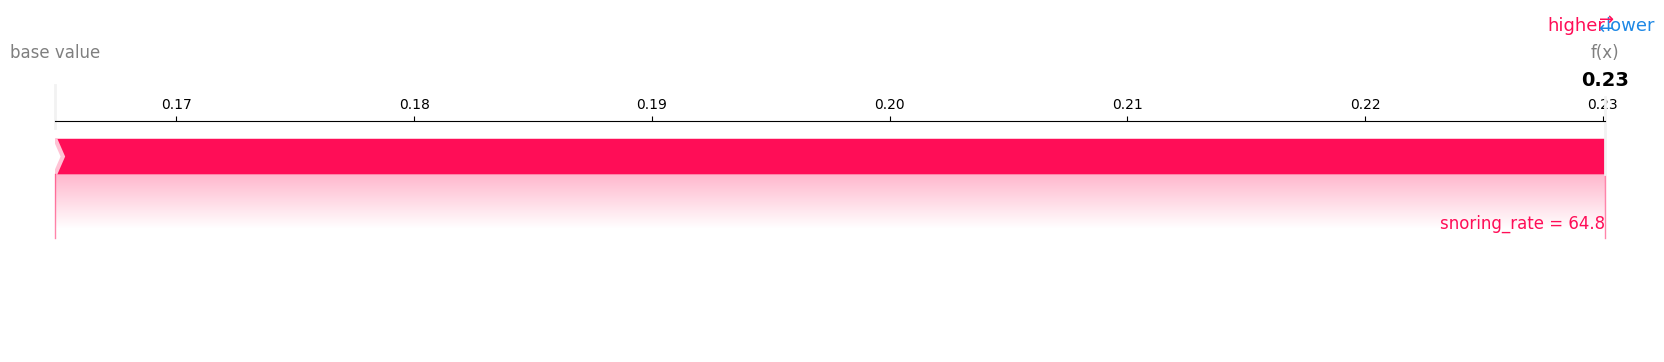

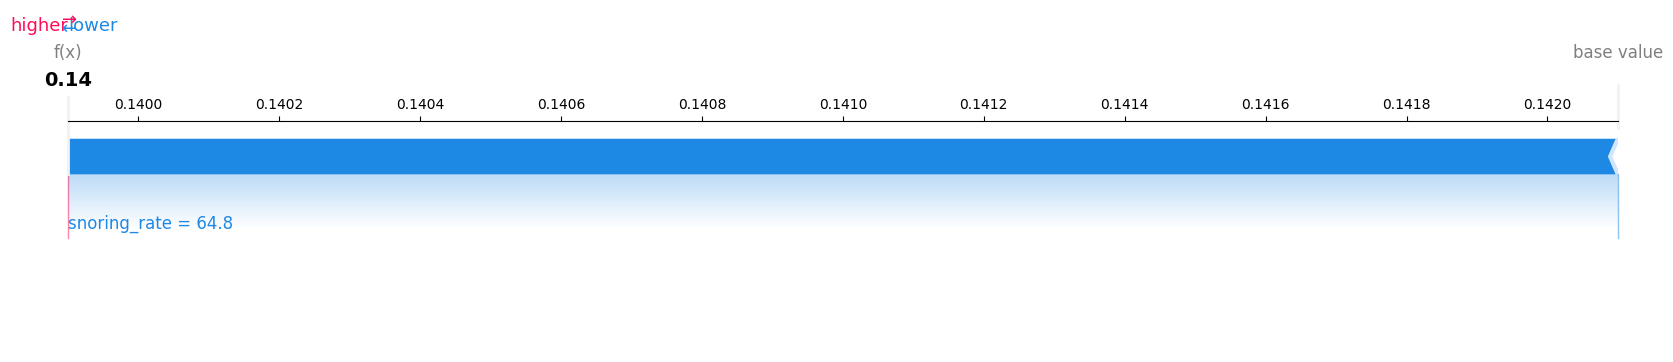

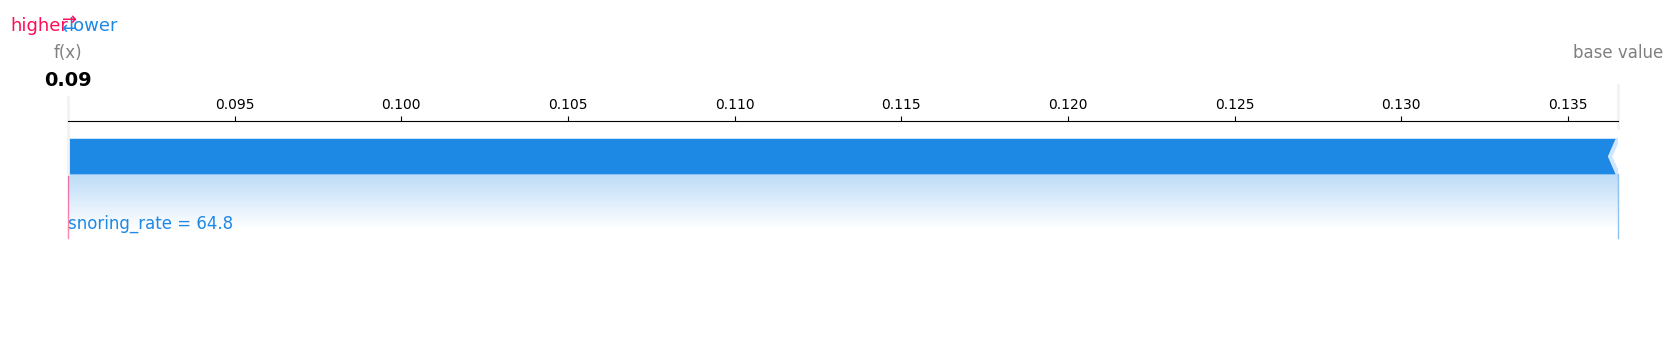

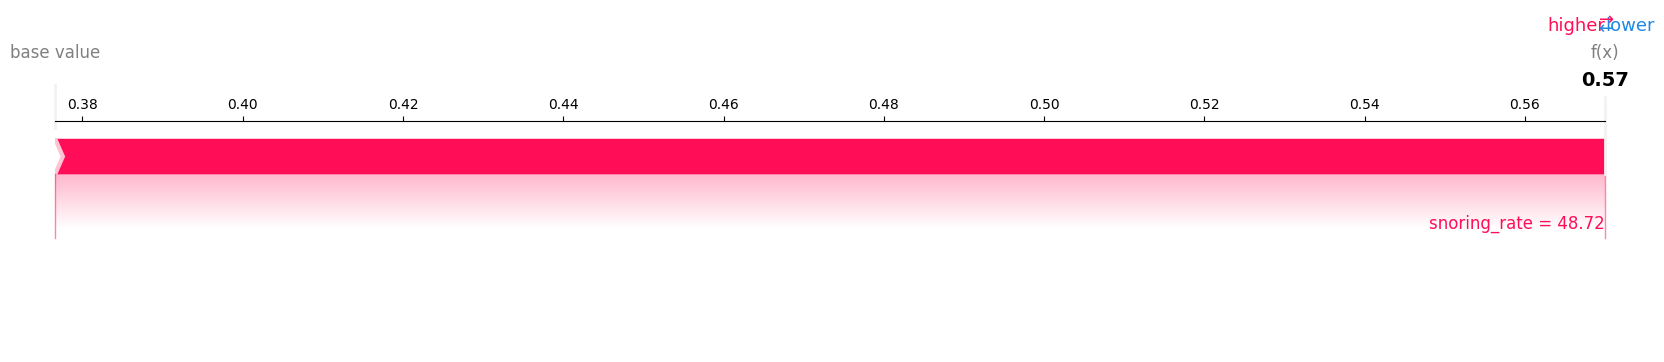

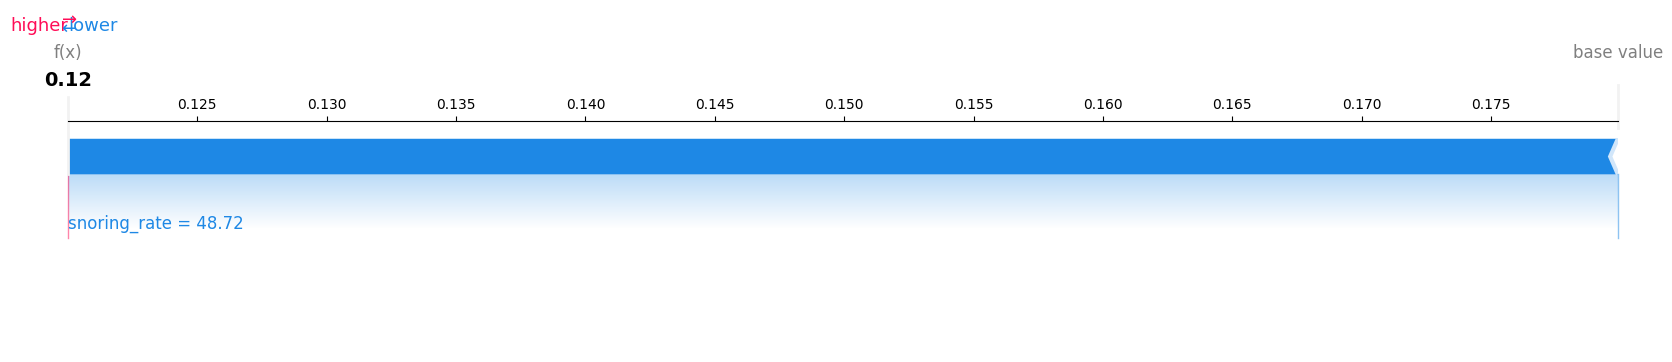

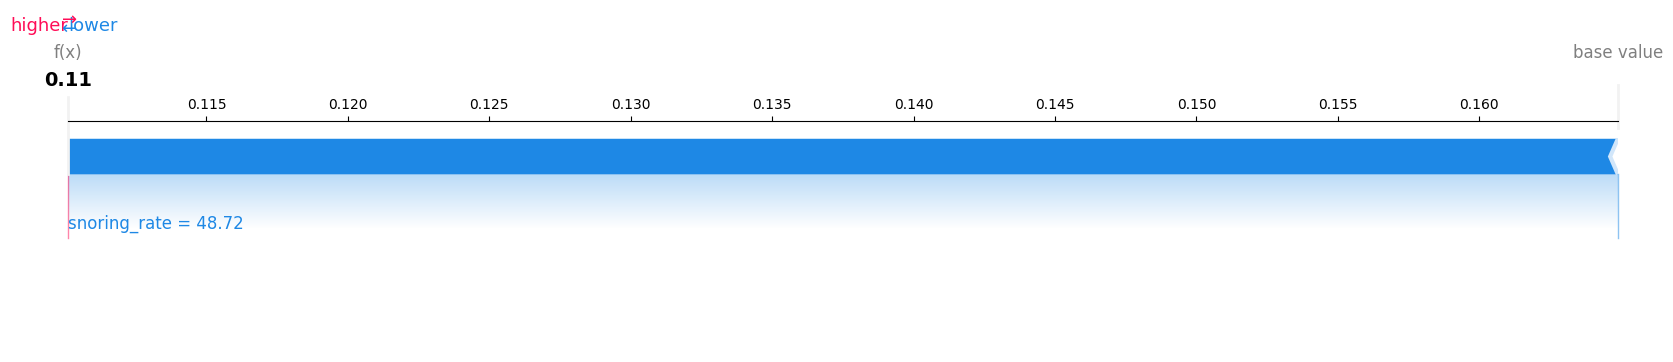

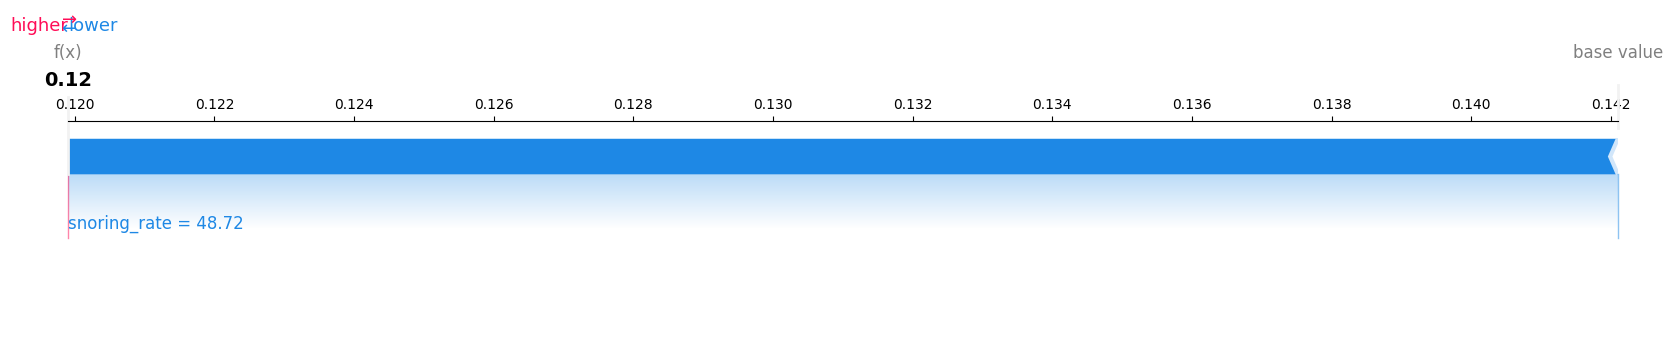

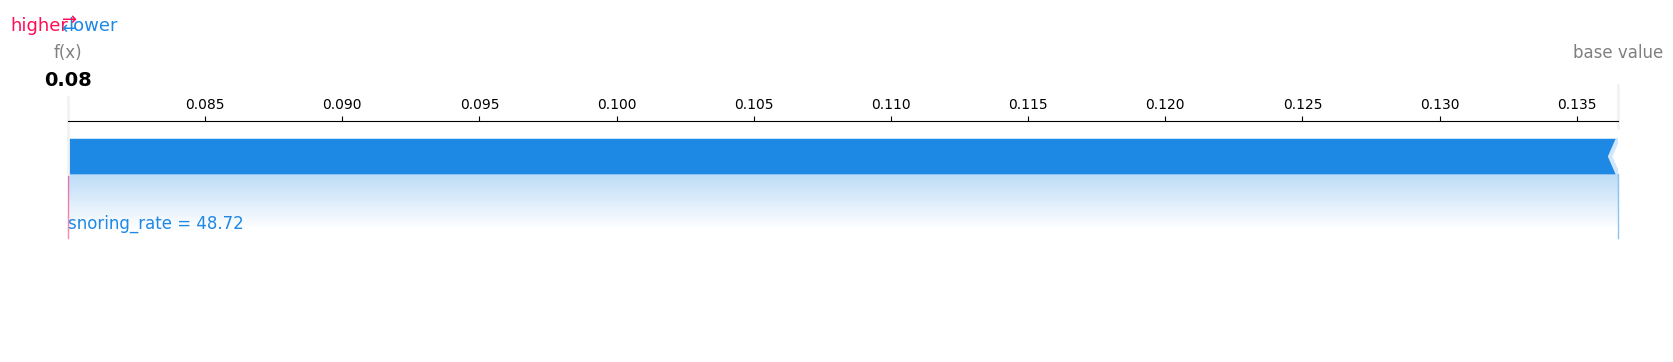

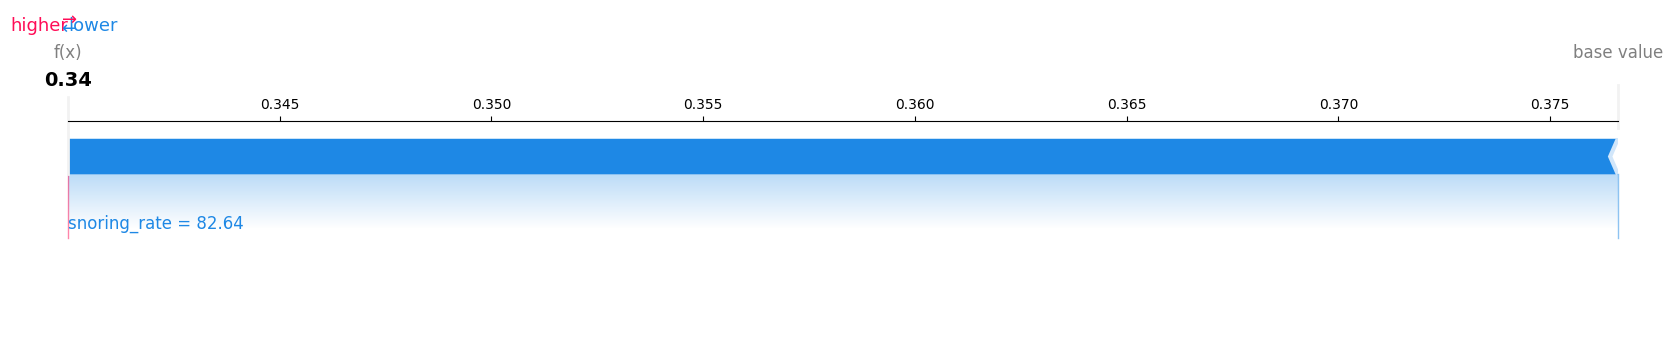

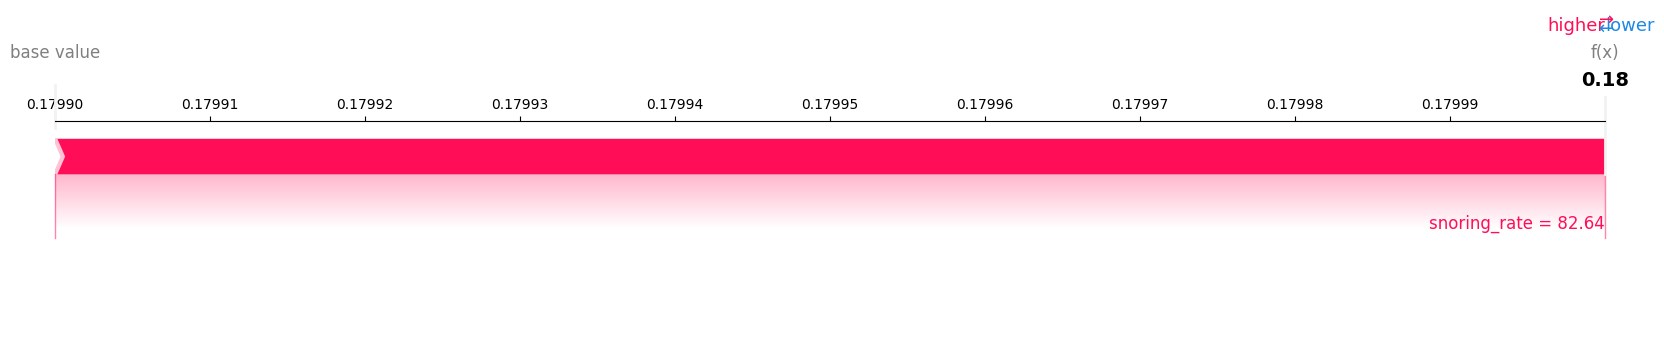

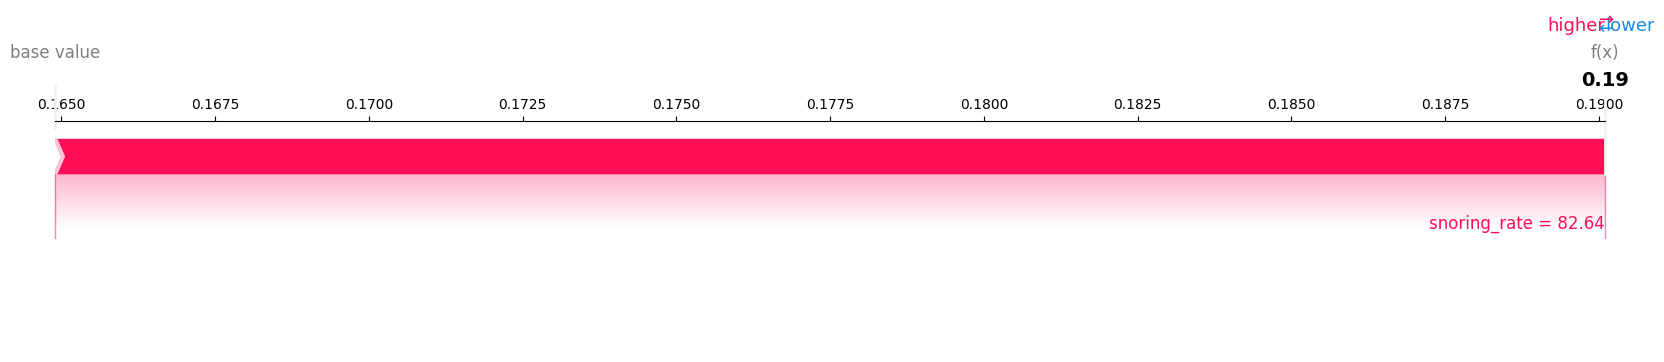

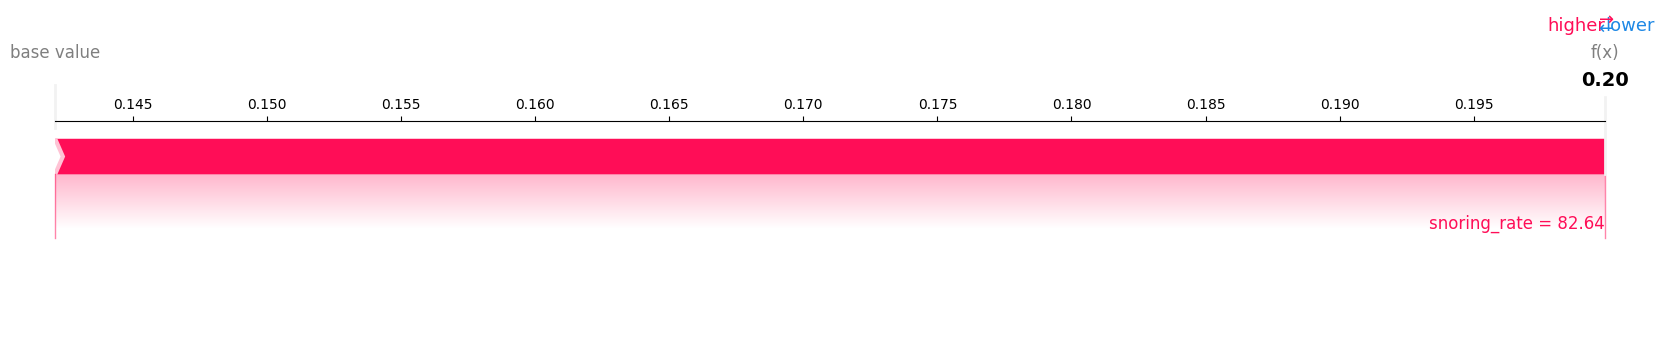

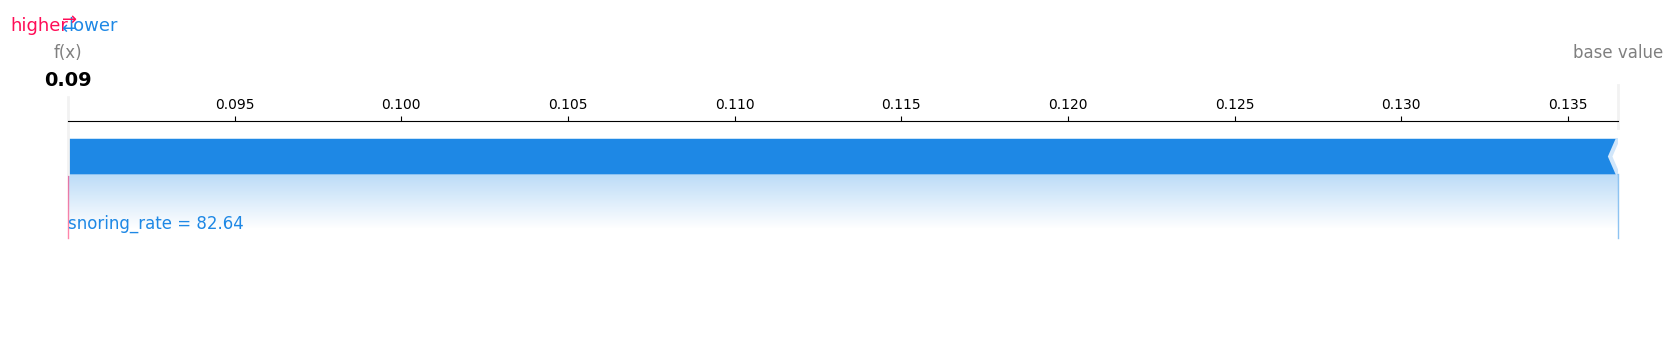

In [ ]:
import shap
import matplotlib.pyplot as plt

num_instances = 5  # Number of instances to display

# Initialize JavaScript for interactive visualizations
shap.initjs()

# Create force plots for each instance
for instance_index in range(num_instances):
    for class_index in range(shap_values.shape[2]):  # Loop through each class
        # Create the Explanation object for the specific instance and class
        explanation = shap.Explanation(
            values=shap_values[instance_index, :, class_index],
            base_values=explainer.expected_value[class_index],
            data=X_test.iloc[instance_index, :],
            feature_names=X_train.columns
        )

        # Display the force plot for the specific instance and class
        shap.force_plot(explanation.base_values, explanation.values, X_test.iloc[instance_index, :], matplotlib=True)

plt.show()


In [ ]:
#shap.plots.force(shap_values[0:100])

### XGBoost without PSO

Accuracy 0.9761904761904762
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.92      0.96        24
           2       0.93      1.00      0.97        28
           3       1.00      0.96      0.98        26
           4       1.00      1.00      1.00        25

    accuracy                           0.98       126
   macro avg       0.98      0.98      0.98       126
weighted avg       0.98      0.98      0.98       126



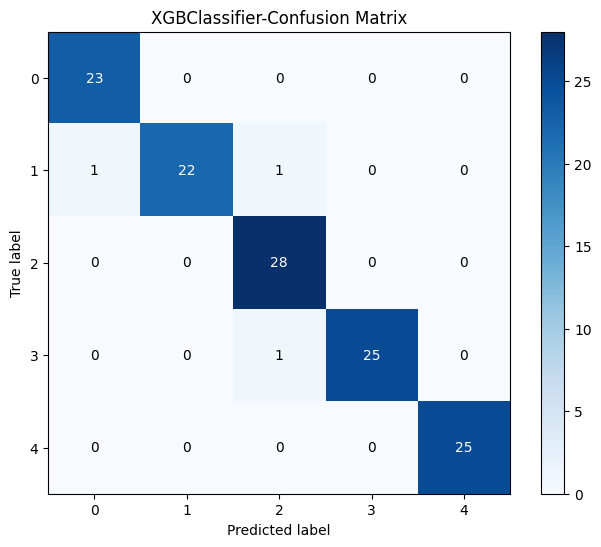

In [ ]:
from xgboost import XGBClassifier

# Train Random Forest classifier using selected features
clf = XGBClassifier(n_estimators=100, random_state=42)
clf.fit(selected_features, y_train)


# Evaluate XGBoost classifier
y_pred = clf.predict(X_test.iloc[:, selected_features_indices])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy",accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('XGBClassifier-Confusion Matrix')
plt.colorbar()

# Add actual values in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# XGboost with PSO

**Hyperparameter Tuning**

In [ ]:
#model = XGBClassifier()
# Define the parameter distribution
#param_dist = {
    'n_estimators': np.arange(100, 1001, 100),
    'max_depth': np.arange(3, 10),
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'colsample_bytree': [0.5, 0.7, 1.0]
}
#random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist,
                                   n_iter=50, scoring='accuracy', cv=3, n_jobs=-1, verbose=2, random_state=42)

#random_search.fit(X_train, y_train)
#print("Best parameters found: ", random_search.best_params_)
#print("Best cross-validation score: ", random_search.best_score_)
#best_model = random_search.best_estimator_
#y_pred = best_model.predict(X_test)
##print("Test set accuracy: ", accuracy)


IndentationError: unexpected indent (<ipython-input-32-3f650e822bab>, line 4)

**Applying PSO**

In [ ]:
# Define the objective function for PSO
def objective_function(feature_indices):
    feature_indices = np.array(feature_indices).astype(int)
    selected_features = X_train.columns[feature_indices.astype(bool)]

    if len(selected_features) == 0:
        return 1.0  # Return high error if no features are selected

    model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    model.fit(X_train[selected_features], y_train)

    predictions = model.predict(X_test[selected_features])
    accuracy = accuracy_score(y_test, predictions)
    return -accuracy

# PSO settings
num_features = X.shape[1]
lb = [0] * num_features
ub = [1] * num_features
#options_randomforest = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 30, 'p': 2}

# Run PSO
best_feature_indices, _ = pso(objective_function, lb, ub, swarmsize=10, maxiter=20)

# Select best features
best_features = np.array(best_feature_indices).astype(int).astype(bool)
selected_features = X.columns[best_features]

# Train XGBoost with selected features
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train[selected_features], y_train)

# Evaluate the model
predictions = model.predict(X_test[selected_features])
accuracy = accuracy_score(y_test, predictions)





/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:58:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:58:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:58:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:58:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:58:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Stopping search: maximum iterations reached --> 20


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:58:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
# Output results
print("Selected Features:", selected_features.tolist())

Selected Features: ['eye_movement', 'sleeping_hours']


In [ ]:
print("Accuracy with Selected Features:", accuracy)

Accuracy with Selected Features: 0.9841269841269841


# KNN

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can change n_neighbors based on your needs

# Train the model
knn.fit(X_train, y_train)
# Make predictions
y_pred = knn.predict(X_test)


Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        28
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        25

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



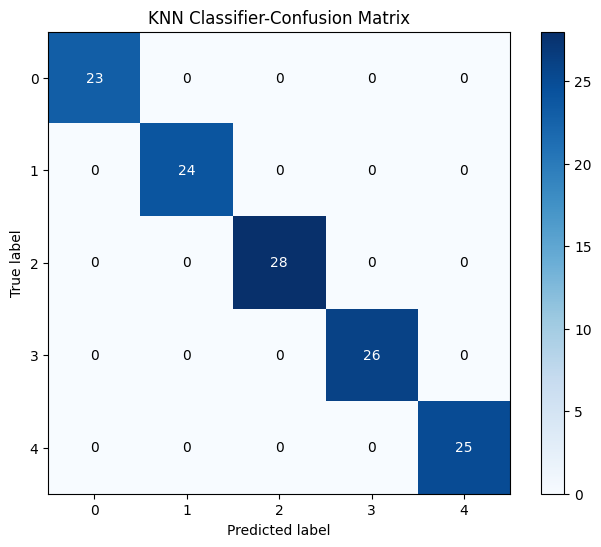

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(class_report)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('KNN Classifier-Confusion Matrix')
plt.colorbar()

# Add actual values in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# KNN with PSO

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the objective function for PSO
def objective_function(feature_indices):
    # Convert feature indices to binary mask
    feature_mask = np.array(feature_indices) > 0.5
    selected_features = X.columns[feature_mask]

    # Handle case where no features are selected
    if len(selected_features) == 0:
        return 1.0  # High error if no features are selected

    # Train KNN with selected features
    knn = KNeighborsClassifier(n_neighbors=5)  # Adjust n_neighbors as needed
    knn.fit(X_train[:, feature_mask], y_train)

    # Make predictions and calculate accuracy
    predictions = knn.predict(X_test[:, feature_mask])
    accuracy = accuracy_score(y_test, predictions)
    return -accuracy  # Minimize negative accuracy

# PSO settings
num_features = X.shape[1]
lb = [0] * num_features  # Lower bounds for features (0 = not selected)
ub = [1] * num_features  # Upper bounds for features (1 = selected)

# Run PSO
best_feature_indices, _ = pso(objective_function, lb, ub, swarmsize=10, maxiter=20)

# Select best features
best_features = np.array(best_feature_indices) > 0.5
selected_features = X.columns[best_features]

# Train KNN with selected features
knn = KNeighborsClassifier(n_neighbors=5)  # Adjust n_neighbors as needed
knn.fit(X_train[:, best_features], y_train)

# Evaluate the model
predictions = knn.predict(X_test[:, best_features])
accuracy = accuracy_score(y_test, predictions)





Stopping search: maximum iterations reached --> 20


In [ ]:
print("Selected Features:", selected_features.tolist())

Selected Features: ['respiration_rate', 'body_temperature', 'eye_movement', 'sleeping_hours']


In [ ]:
print("Accuracy with Selected Features:", accuracy)

Accuracy with Selected Features: 1.0


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Create and train the Decision Tree classifier
tree_classifier = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters here
tree_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = tree_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Print classification report for more detailed evaluation
print(classification_report(y_test, y_pred))

Accuracy: 0.9761904761904762
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.92      0.96        24
           2       0.93      1.00      0.97        28
           3       1.00      0.96      0.98        26
           4       1.00      1.00      1.00        25

    accuracy                           0.98       126
   macro avg       0.98      0.98      0.98       126
weighted avg       0.98      0.98      0.98       126



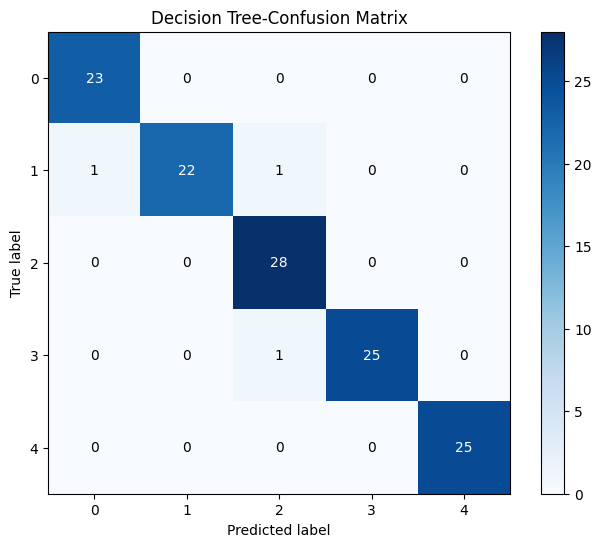

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Decision Tree-Confusion Matrix')
plt.colorbar()

# Add actual values in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

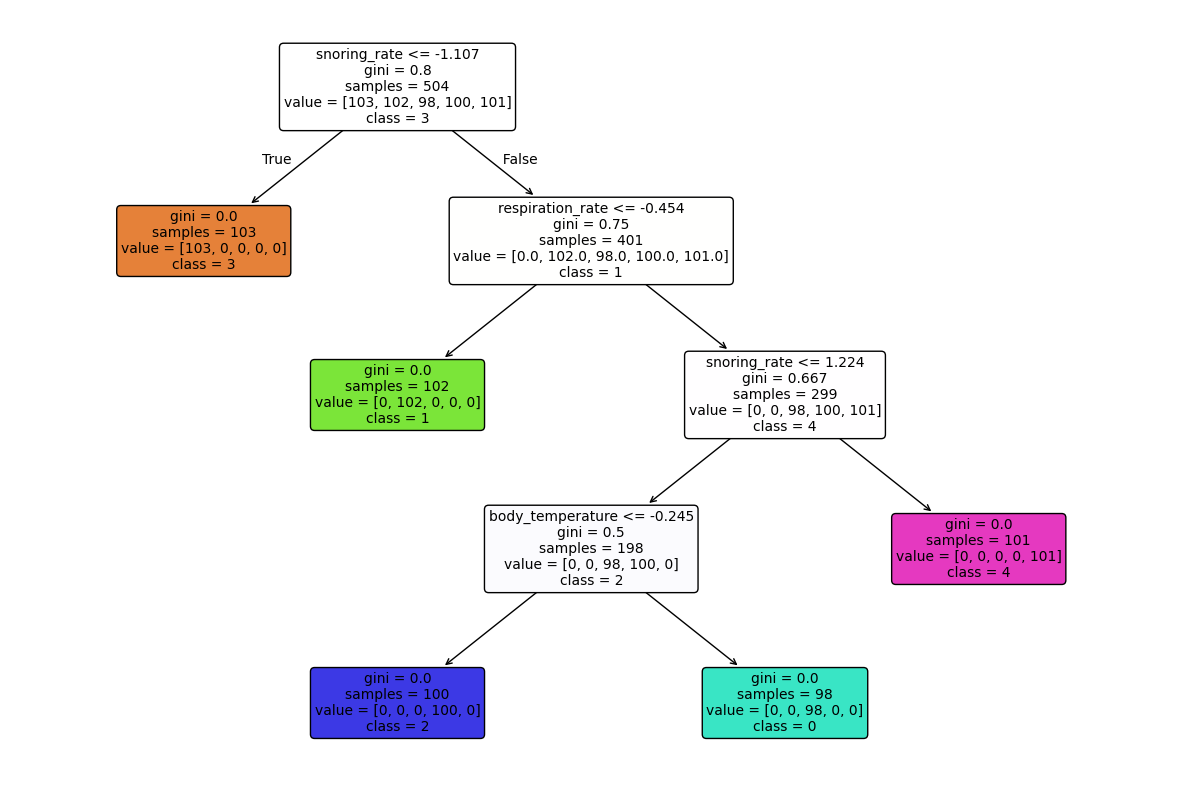

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
class_names = [str(c) for c in y.unique()]
plot_tree(tree_classifier, filled=True, feature_names=X.columns, class_names=class_names, rounded=True, fontsize=10)
plt.show()


# Decision Tree with PSO

In [ ]:
# Define the objective function for PSO
def objective_function(feature_indices):
    # Convert feature indices to binary mask
    feature_mask = np.array(feature_indices) > 0.5
    selected_features = X.columns[feature_mask]

    # Handle case where no features are selected
    if len(selected_features) == 0:
        return 1.0  # High error if no features are selected


    # Train Decision Tree with selected features
    tree_classifier = DecisionTreeClassifier(random_state=42)
    tree_classifier.fit(X_train[:, feature_mask], y_train)

    # Make predictions and calculate accuracy
    predictions = tree_classifier.predict(X_test[:, feature_mask])  # Bracket indexing
    accuracy = accuracy_score(y_test, predictions)
    return -accuracy  # Minimize negative accuracy

# PSO settings
num_features = X.shape[1]
lb = [0] * num_features  # Lower bounds for features (0 = not selected)
ub = [1] * num_features  # Upper bounds for features (1 = selected)

# Run PSO
best_feature_indices, _ = pso(objective_function, lb, ub, swarmsize=10, maxiter=20)

# Select best features
best_features = np.array(best_feature_indices) > 0.5
selected_features = X.columns[best_features]


# Train Decision Tree with selected features
tree_classifier = DecisionTreeClassifier(random_state=42)
tree_classifier.fit(X_train[:, best_features], y_train)

# Evaluate the model
predictions = tree_classifier.predict(X_test[:, best_features])
accuracy = accuracy_score(y_test, predictions)

Stopping search: maximum iterations reached --> 20


In [ ]:
print("Selected Features:", selected_features.tolist())

Selected Features: ['respiration_rate', 'limb_movement', 'sleeping_hours']


In [ ]:
print("Accuracy with Selected Features:", accuracy)

Accuracy with Selected Features: 0.9841269841269841


# SVM

In [ ]:
from sklearn.svm import SVC

svm_classifier = SVC(kernel='rbf', random_state=42)  # You can change the kernel type if needed
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Print classification report for more detailed evaluation
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        28
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        25

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



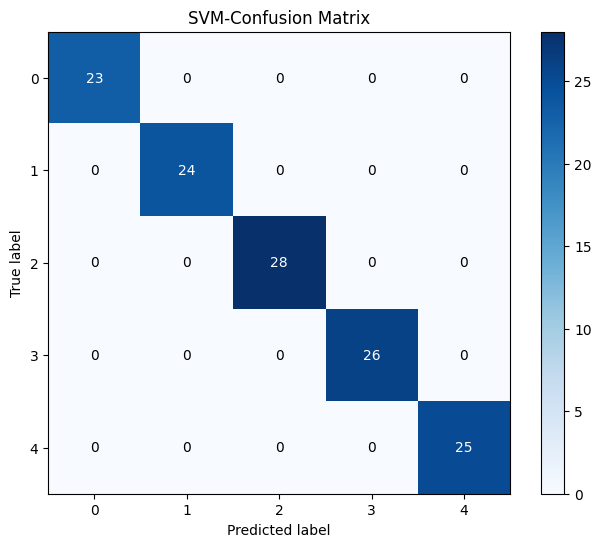

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('SVM-Confusion Matrix')
plt.colorbar()

# Add actual values in each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# SVM with PSO

In [ ]:
# Define the objective function for PSO
def objective_function(feature_indices):
    # Convert feature indices to binary mask
    feature_mask = np.array(feature_indices) > 0.5
    selected_features = X.columns[feature_mask]

    # Handle case where no features are selected
    if len(selected_features) == 0:
        return 1.0  # High error if no features are selected

  # Train SVM with selected features
    svm_classifier = SVC(kernel='rbf', random_state=42)  # You can change the kernel type
    svm_classifier.fit(X_train[:, feature_mask], y_train)  # NumPy indexing with integer indices

    # Make predictions and calculate accuracy
    predictions = svm_classifier.predict(X_test[:, feature_mask])  # Bracket indexing
    accuracy = accuracy_score(y_test, predictions)
    return -accuracy  # Minimize negative accuracy

# PSO settings
num_features = X.shape[1]
lb = [0] * num_features  # Lower bounds for features (0 = not selected)
ub = [1] * num_features  # Upper bounds for features (1 = selected)

# Run PSO
best_feature_indices, _ = pso(objective_function, lb, ub, swarmsize=10, maxiter=20)

# Select best features
best_features = np.array(best_feature_indices) > 0.5
selected_features = X.columns[best_features]


# Train Decision Tree with selected features
svm_classifier = SVC(kernel='rbf', random_state=42)
svm_classifier.fit(X_train[:, best_features], y_train)

# Evaluate the model
y_pred = svm_classifier.predict(X_test[:, best_features])
accuracy = accuracy_score(y_test,y_pred)

Stopping search: maximum iterations reached --> 20


In [ ]:
print("Selected Features:", selected_features.tolist())

Selected Features: ['snoring_rate', 'body_temperature', 'eye_movement']


In [ ]:
print("Accuracy with Selected Features:", accuracy)

Accuracy with Selected Features: 1.0


### Lime

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=98eed1666a6b10e5769e8f569ce3f1f8f49f0eb41738ea3d0c00a64df98e201e
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular
from lime.lime_tabular import LimeTabularExplainer


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[1]


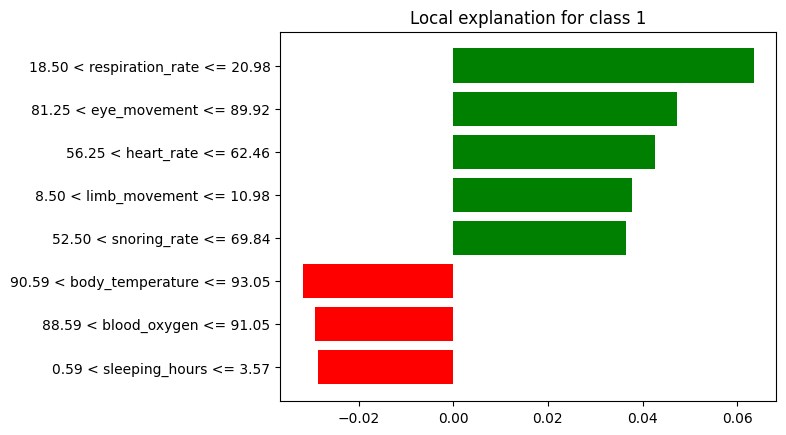

In [ ]:
# Create a Random Forest classifier
#clf = RandomForestClassifier(n_estimators=100, random_state=42)
#clf.fit(X_train, y_train)

# Create a LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns.tolist(), class_names=y_train.unique(), discretize_continuous=True, mode='classification')
sample_idx = 5
sample = X_test.iloc[sample_idx]
true_class = y_test.iloc[sample_idx]
explanation = explainer.explain_instance(sample.values, clf.predict_proba, num_features=len(X_train.columns))
explanation.show_in_notebook()
explanation.as_pyplot_figure()
print(explanation.available_labels())